<a href="https://colab.research.google.com/github/MatteoBaraldi/Machine-Learning-for-Bioengineering/blob/main/MOD-1/notebooks/03_age_prediction_eda_regression_holdout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Age Prediction: data preparation, Exploratory Data Analysis (EDA), and regression with hold-out & nested hold-out validation

## Data Preparation and Exploratory Data Analysis (EDA)

Import libraries

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR #we'll need it at the end

Loading and showing input (features) and output data (desired output)

In [ ]:
df = pd.read_excel('https://raw.githubusercontent.com/sdiciotti/Age-Prediction-Demo/main/NKI2_data.xlsx')
print (type(df))

<class 'pandas.core.frame.DataFrame'>


Print the size of the dataframe

In [ ]:
df.shape

(73, 35)

Print the dataframe

In [ ]:
print(df)

Check the features and output variables name

In [ ]:
features = list(df.columns)
type(features)

list

In [ ]:
print(features)

['Age', 'Sex', 'cortex_CT', 'lh_cortex_CT', 'rh_cortex_CT', 'lh_frontalGM_CT', 'lh_occipitalGM_CT', 'lh_temporalGM_CT', 'lh_parietalGM_CT', 'rh_frontalGM_CT', 'rh_occipitalGM_CT', 'rh_temporalGM_CT', 'rh_parietalGM_CT', 'cortex_pial_lgi', 'lh_cortex_pial_lgi', 'rh_cortex_pial_lgi', 'lh_frontal_pial_lgi', 'lh_occipital_pial_lgi', 'lh_temporal_pial_lgi', 'lh_parietal_pial_lgi', 'rh_frontal_pial_lgi', 'rh_occipital_pial_lgi', 'rh_temporal_pial_lgi', 'rh_parietal_pial_lgi', 'cerebralGM_FD', 'lh_cerebralGM_FD', 'lh_frontalGM_FD', 'lh_temporalGM_FD', 'lh_parietalGM_FD', 'lh_occipitalGM_FD', 'rh_cerebralGM_FD', 'rh_frontalGM_FD', 'rh_temporalGM_FD', 'rh_parietalGM_FD', 'rh_occipitalGM_FD']


Plotting some data

Text(0, 0.5, 'cortex CT (mm)')

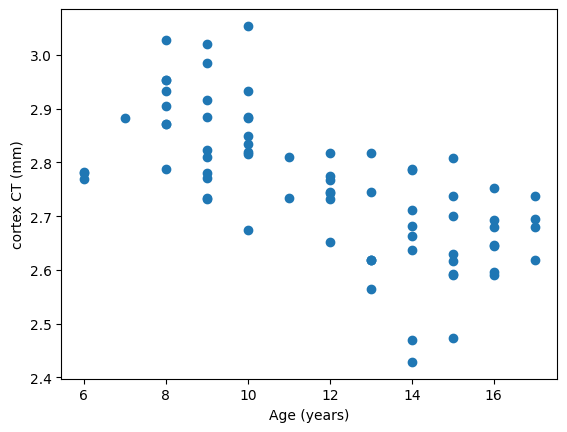

In [ ]:
# Plot true vs predicted values to visualize model performance
plt.scatter(df['Age'],df['cortex_CT'])
plt.xlabel('Age (years)')
plt.ylabel('cortex CT (mm)')

In [ ]:
print("Dataframe shape before NaN removal:", df.shape)

Dataframe shape before NaN removal: (73, 35)


Removing missing data

In [ ]:
df.dropna(axis=0, how='any', inplace=True)
print("Dataframe shape after NaN removal:", df.shape)

Dataframe shape after NaN removal: (72, 35)


Preparing the design matrix X and the desired output y

In [ ]:
X = df.iloc[:,2::]
y = df['Age']
print (type(X))
print (type(y))
print (X.shape)
print (y.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
(72, 33)
(72,)


A quick quality control

In [ ]:
X.head(6)

In [ ]:
print('The whole dataset contains ' + str(X.shape[0]) + ' subjects')
print('The age prediction will be performed using ' + str(X.shape[1]) + ' MRI-derived features')

The whole dataset contains 72 subjects
The age prediction will be performed using 33 MRI-derived features


## Regression task

### Linear Regression using a hold-out validation scheme

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Setting the seed of the random generator
SEED = 42 #reference to The Hitchiker's Guide to the Galaxy, we need to set it to have the same pseudo-random values each time

# Size of the samples in the test set: e.g., 0.1, means that the test set is composed of 10% of the samples of the entire dataset
test_size = 0.1 #10% of the data will be test set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=SEED) #does the separation

In [ ]:
type(X_train) #asks for the type of the matrix generated (DataFrame)

pandas.core.frame.DataFrame

In [ ]:
type(y_train) #= (Series)

pandas.core.series.Series

In [ ]:
# Print the shape of the training and test sets
print (X_train.shape, y_train.shape)
print (X_test.shape, y_test.shape)

(64, 33) (64,)
(8, 33) (8,)


In [ ]:
X_train.head(2) #return the first 2 rows of X_train

In [ ]:
y_train.head(2)

In [ ]:
# Calculate the Mean Absolute Error (MAE) to evaluate model performance
# Fitting the linear model
reg = LinearRegression().fit(X_train, y_train) #evaluate the best coefficients and returns the mathematical formula based on training set

# Applying the final model to the test set samples
y_pred = reg.predict(X_test) #takes the model implemented and gives it the test set, returns predictions
#in this string we dont use y_test still but we make blind predictions based on the training

# Compute the MAE in the test set
MAE = mean_absolute_error(y_test, y_pred) #evaluates the MAE of the model on the test set
#it takes the real value (y_test) and the predicted one (y_pred) and calculate the MAE
print ("MAE test set:", MAE, "years")

MAE test set: 1.4109915646679987 years


In [ ]:
type(y_pred)

numpy.ndarray

### Polynomial regression using a nested hold-out validation scheme

In [ ]:
from sklearn.model_selection import train_test_split
#here we perform a double splitting

# Setting the seed of the random generator
SEED = 42

# Size of the samples in the test set: e.g., 0.1, means that the test set is composed of 10% of the samples of the entire dataset
test_size = 0.1

# Size of the samples in the validation set: e.g., 0.1, means that the test set is composed of 10% of the samples of the development set
val_size = 0.1 #validation set will be 10%

# Outer hold-out (development and test)
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=test_size, random_state=SEED)

# Print the size of the development and test sets
print ("The development set size is", "X:", X_dev.shape, "y:", y_dev.shape)
print ("The test set size is", "X:", X_test.shape, "y:", y_test.shape)

# Inner hold-out (training and validation)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=val_size, random_state=SEED)
# Print the size of the training and validation sets
print ("\nThe development set size is", "X:", X_train.shape, "y:", y_train.shape)
print ("The test set size is", "X:", X_val.shape, "y:", y_val.shape)
print()


The development set size is X: (64, 33) y: (64,)
The test set size is X: (8, 33) y: (8,)

The development set size is X: (57, 33) y: (57,)
The test set size is X: (7, 33) y: (7,)



*** Polynomial degree: 1 MAE: 1.529087405773741
*** Polynomial degree: 2 MAE: 2.0430609668447874
*** Polynomial degree: 3 MAE: 2.019123282529224
*** Polynomial degree: 4 MAE: 2.002122399598142
*** Polynomial degree: 5 MAE: 2.003922839417611

Best polynomial degree: 1 MAE: 1.529087405773741 years
MAE test set: 1.4109915646680058 years


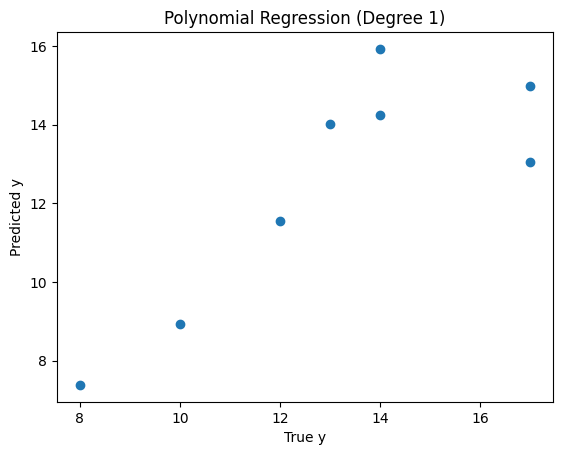

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

MAE = []
degree_list = [1, 2, 3, 4, 5]  # List of polynomial degrees to test

for d in degree_list:
    poly = PolynomialFeatures(degree=d) #configure the transformation using the actual degree
    X_train_poly = poly.fit_transform(X_train) #study the training set structure and determine the geometry (x^2, x^n ecc.)
    X_val_poly = poly.transform(X_val) #use the same transformation on the validation set (no fit)

    reg = LinearRegression().fit(X_train_poly, y_train) #create the model and train it calculating the weights
    y_val_pred = reg.predict(X_val_poly) #obtain predictions using the weights

    MAE_d = mean_absolute_error(y_val, y_val_pred) #compute the MAE for the order d on the validation set
    print("*** Polynomial degree:", d, "MAE:", MAE_d)
    MAE.append(MAE_d) #memorize the MAE

# Find the best degree with the lowest MAE
best_degree_index = np.argmin(MAE) #index at which we find the lowest MAE
best_degree = degree_list[best_degree_index] #value of the lowest MAE
print("\nBest polynomial degree:", best_degree, "MAE:", MAE[best_degree_index], "years")

# Re-train the Polynomial Regression model on the development set using the best degree
poly = PolynomialFeatures(degree=best_degree) #impost a new polynomial using the best degree just found
X_dev_poly = poly.fit_transform(X_dev) #transform the whole developmente set for final training
X_test_poly = poly.transform(X_test) #transform the test set using the same transformation

reg = LinearRegression().fit(X_dev_poly, y_dev) #train and compute the final weights on the whole development set

# Apply the model to the test set and compute the MAE
y_test_pred = reg.predict(X_test_poly) #generates the final predictions on the test set
MAE_test = mean_absolute_error(y_test, y_test_pred) #compute the final MAE
print("MAE test set:", MAE_test, "years")

# Plot predictions in the test set
plt.scatter(y_test, y_test_pred)
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title(f'Polynomial Regression (Degree {best_degree})')
plt.show()

### Support Vector Regressor with hyperparameter C (Complexity) using a nested hold-out validation scheme

*** C value: 0.1 MAE: 2.744695146993926
*** C value: 1 MAE: 2.157673642649064
*** C value: 10 MAE: 1.7345360725342982

Best C:  10 MAE 1.7345360725342982 years
MAE test set: 1.8307604143733762 years


Text(0, 0.5, 'predicted y')

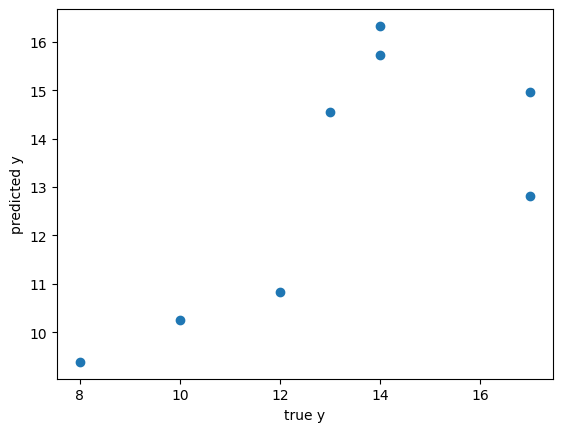

In [ ]:

MAE = []
C_list = [0.1, 1, 10] #candidates as hyperparameters
for c in C_list: #tries every C
    reg = SVR(kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001, C=c, epsilon=0.1, shrinking=True, cache_size=200, verbose=0, max_iter=- 1).fit(X_train, y_train)
    #initliaze the Support Vector Regressor model with the parameters listed, then .fit trains it on training set computing weights and optimal support vectors
    y_val_pred = reg.predict(X_val) #generates predictions for the validation set
    MAE_c = mean_absolute_error(y_val, y_val_pred) #compute MAE relative to that C
    print ("*** C value:", c, "MAE:", MAE_c)
    MAE.append (MAE_c) #store the value
bestC_index = np.argmin(MAE) #index of the best MAE in the MAE vector
bestC = C_list[bestC_index] #value of the best MAE
print ("\nBest C: ", bestC, "MAE", MAE[bestC_index], "years")

# Re-train the SVR model in the development test using the bestC hyperparameter
reg = SVR(kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001, C=bestC, epsilon=0.1, shrinking=True, cache_size=200, verbose=0, max_iter=- 1).fit(X_dev, y_dev)

# Apply the model to the test set and compute the MAE
y_test_pred = reg.predict(X_test) #compute predictions on the test set
MAE = mean_absolute_error(y_test, y_test_pred) #compute and print final MAE
print ("MAE test set:", MAE, "years")

# Plot predictions in the test set
plt.scatter(y_test,y_test_pred)
plt.xlabel('true y')
plt.ylabel('predicted y')